In [1]:
import numpy as np
import pandas as pd

In [2]:
# pd.multiIndex.fr0m_tuples()

value_ind= [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
multiIndexx= pd.MultiIndex.from_tuples(value_ind)
multiIndexx

MultiIndex([('cse', 2019),
            ('cse', 2020),
            ('cse', 2021),
            ('cse', 2022),
            ('ece', 2019),
            ('ece', 2020),
            ('ece', 2021),
            ('ece', 2022)],
           )

In [3]:
# pd.MultiIndex.from_product

pd.MultiIndex.from_product([['cse','ece'],[2019,2020,2021,2022]])

MultiIndex([('cse', 2019),
            ('cse', 2020),
            ('cse', 2021),
            ('cse', 2022),
            ('ece', 2019),
            ('ece', 2020),
            ('ece', 2021),
            ('ece', 2022)],
           )

In [4]:
s=pd.Series([1,2,3,4,5,6,7,8], index=multiIndexx)
s

cse  2019    1
     2020    2
     2021    3
     2022    4
ece  2019    5
     2020    6
     2021    7
     2022    8
dtype: int64

In [5]:
s.unstack()

,2019,2020,2021,2022
cse,1,2,3,4
ece,5,6,7,8


In [6]:
s.stack()

AttributeError: 'Series' object has no attribute 'stack'

In [7]:
import pandas as pd

df = pd.DataFrame({
    "Name": ["A","B"],
    "Math": [80,90],
    "Science": [70,85],
    "english":[56,89]
})

# Melt
long_df = pd.melt(df, id_vars=["Name"],
                  var_name="Subject",
                  value_name="Marks")

print(long_df)

# Pivot
wide_df = long_df.pivot(index="Name",
                        columns="Subject",
                        values="Marks")

print(wide_df)

# Pivot Table 
pivot_t = long_df.pivot_table(index="Name",
                             columns="Subject",
                             values="Marks",
                             aggfunc="mean")

print(pivot_t)

  Name  Subject  Marks
0    A     Math     80
1    B     Math     90
2    A  Science     70
3    B  Science     85
4    A  english     56
5    B  english     89
Subject  Math  Science  english
Name                           
A          80       70       56
B          90       85       89
Subject  Math  Science  english
Name                           
A        80.0     70.0     56.0
B        90.0     85.0     89.0


In [8]:
df = pd.DataFrame({
    "Name": ["A","A","B"],
    "Subject": ["Math","Science","Math"],
    "Marks": [80,90,70]
})
df.pivot(index='Name',
         columns='Subject',
         values='Marks')

Subject,Math,Science
Name,,
A,80.0,90.0
B,70.0,NaN


In [9]:
# pilot_table
import seaborn as sns

In [10]:
df=sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [11]:
df.groupby('sex')[['total_bill']].mean()

C:\Users\bgspu\AppData\Local\Temp\ipykernel_17076\2388094044.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('sex')[['total_bill']].mean()


,total_bill
sex,
Male,20.744076
Female,18.056897


In [12]:
df.groupby(['sex','smoker'])['total_bill'].mean().unstack()

C:\Users\bgspu\AppData\Local\Temp\ipykernel_17076\2279680371.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['sex','smoker'])['total_bill'].mean().unstack()


smoker,Yes,No
sex,,
Male,22.284500,19.791237
Female,17.977879,18.105185


In [13]:
df.pivot_table(index='sex', columns='smoker', values='total_bill')

C:\Users\bgspu\AppData\Local\Temp\ipykernel_17076\2612546575.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex', columns='smoker', values='total_bill')


smoker,Yes,No
sex,,
Male,22.284500,19.791237
Female,17.977879,18.105185


In [18]:
# aggfunc

df.pivot_table(index='sex', columns='smoker', values='total_bill', aggfunc='mean')

C:\Users\bgspu\AppData\Local\Temp\ipykernel_17076\851708486.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex', columns='smoker', values='total_bill', aggfunc='mean')


smoker,Yes,No
sex,,
Male,22.284500,19.791237
Female,17.977879,18.105185


In [20]:
df=pd.read_csv('Dataset/expense_data.csv')
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


In [23]:
df['Category'].value_counts()

Category
Food                156
Other                60
Transportation       31
Apparel               7
Household             6
Allowance             6
Social Life           5
Education             1
Salary                1
Self-development      1
Beauty                1
Gift                  1
Petty cash            1
Name: count, dtype: int64

In [29]:
df['Date']=pd.to_datetime(df['Date'])

In [24]:
df['Date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 277 entries, 0 to 276
Series name: Date
Non-Null Count  Dtype 
--------------  ----- 
277 non-null    object
dtypes: object(1)
memory usage: 2.3+ KB


In [31]:
df['month']=df['Date'].dt.month_name()
df['month'].head()

0    March
1    March
2    March
3    March
4    March
Name: month, dtype: object

<Axes: xlabel='month'>

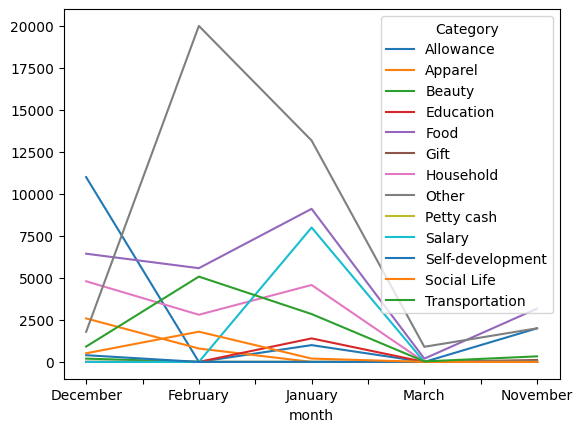

In [34]:
df.pivot_table(index='month', columns='Category', values='INR', aggfunc='sum', fill_value=0).plot()

<Axes: xlabel='Note'>

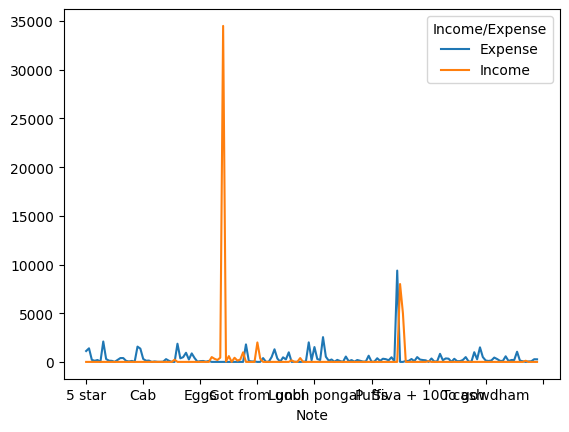

In [41]:
df.pivot_table(index='Note', columns='Income/Expense', values='INR', aggfunc='sum', fill_value=5).plot()